# <a id='toc1_'></a>[**Classification of Waste Products Using Transfer Learning**](#toc0_)


### <a id='toc1_1_'></a>[Introduction](#toc0_)
In this project, we will classify waste products using transfer learning. 

### <a id='toc1_1_1_'></a>[Project Overview](#toc0_)

The manual sorting of waste is not only labor-intensive but also prone to errors, leading to contamination of recyclable materials. The goal of this project is to leverage machine learning and computer vision to automate the classification of waste products, improving efficiency and reducing contamination rates. The project will use transfer learning with a pre-trained VGG16 model to classify images.

### <a id='toc1_1_2_'></a>[Aim of the Project](#toc0_)

The aim of the project is to develop an automated waste classification model that can accurately differentiate between recyclable and organic waste based on images. By the end of this project, we will have trained, fine-tuned, and evaluated a model using transfer learning, which can then be applied to real-world waste management processes.

**Final Output**: A trained model that classifies waste images into recyclable and organic categories.



## <a id='toc1_3_'></a>[Setup](#toc0_)

For this project, we will be using the following libraries:

* `numpy`
* `sklearn`
* `matplotlib`
* `tensorflow`

### <a id='toc1_3_1_'></a>[Installing Required Libraries](#toc0_)


In [ ]:
!pip install tensorflow==2.17.0 
!pip install numpy==1.26.0
!pip install scikit-learn==1.5.1  
!pip install matplotlib==3.9.2

### <a id='toc1_3_2_'></a>[Importing Required Libraries](#toc0_)

In [ ]:
import numpy as np
import os
import glob

from matplotlib import pyplot as plt
from matplotlib import pyplot
from matplotlib.image import imread

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn import metrics

import warnings
warnings.filterwarnings('ignore')

## <a id='toc1_5_'></a>[Background](#toc0_)


**Transfer learning** uses the concept of keeping the early layers of a pre-trained network, and re-training the later layers on a specific dataset.

A typical transfer learning workflow in Keras looks something like this:

1.  Initialize base model, and load pre-trained weights (e.g. ImageNet)
2.  "Freeze" layers in the base model by setting `training = False`
3.  Define a new model that goes on top of the output of the base model's layers.
4.  Train resulting model on your data set.

## <a id='toc1_6_'></a>[Create a model for distinguishing recyclable and organic waste images](#toc0_)

### <a id='toc1_6_1_'></a>[Dataset](#toc0_)

we will be using the [Waste Classification Dataset](https://www.kaggle.com/datasets/techsash/waste-classification-data?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01).

Our goal is to train an algorithm on these images and to predict the labels for images in your test set (1 = recyclable, 0 = organic).



### <a id='toc1_6_3_'></a>[Define configuration options](#toc0_)

It's time to define some model configuration options.

*   **batch size** is set to 32.
*   The **number of classes** is 2.
*   We will use 20% of the data for **validation** purposes.
*   We have two **labels** in our dataset: organic (O), recyclable (R).


In [4]:
img_rows, img_cols = 150, 150
batch_size = 32
n_epochs = 10
n_classes = 2
val_split = 0.2
verbosity = 1
path = './Dataset/o-vs-r-split/train/'
path_test = './Dataset/o-vs-r-split/test/'
input_shape = (img_rows, img_cols, 3)
labels = ['O', 'R']
seed = 42

### <a id='toc1_6_4_'></a>[Loading Images using ImageGeneratorClass](#toc0_)

Transfer learning works best when models are trained on smaller datasets. 


#### <a id='toc1_6_4_1_'></a>[ImageDataGenerators](#toc0_)


Now we will create ImageDataGenerators used for training, validation and testing.

Image data generators create batches of tensor image data with real-time data augmentation. The generators loop over the data in batches and are useful in feeding data to the training process. 

In [5]:
# Create ImageDataGenerators for training and validation and testing
train_datagen = ImageDataGenerator(
    validation_split = val_split,
    rescale=1.0/255.0,
	width_shift_range=0.1, 
    height_shift_range=0.1, 
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    validation_split = val_split,
    rescale=1.0/255.0,
)

test_datagen = ImageDataGenerator(
    rescale=1.0/255.0
)

In [6]:
train_generator = train_datagen.flow_from_directory(
    directory = path,
    seed = seed,
    batch_size = batch_size, 
    class_mode='binary',
    shuffle = True,
    target_size=(img_rows, img_cols),
    subset = 'training'
)

Found 800 images belonging to 2 classes.


In [7]:
val_generator = val_datagen.flow_from_directory(
    directory = path,
    seed = seed,
    batch_size = batch_size, 
    class_mode='binary',
    shuffle = True,
    target_size=(img_rows, img_cols),
    subset = 'validation'
)

Found 200 images belonging to 2 classes.


In [ ]:
# Creating a `test_generator` using the `test_datagen` object
test_generator = test_datagen.flow_from_directory(
    directory= path_test,
    class_mode= "binary",
    seed= seed,
    batch_size= batch_size ,
    shuffle= False,
    target_size= (img_rows, img_cols)
)

Found 200 images belonging to 2 classes.


In [ ]:
# printing the length of the `train_generator`
len_train = len(train_generator)
print(f"Length of train_generator: {len_train}")


Length of train_generator: 25


Let's look at a few augmented images:


### <a id='toc1_6_2_'></a>[Importing Data](#toc0_)

Labels: ['O', 'O', 'O', 'O', 'O']


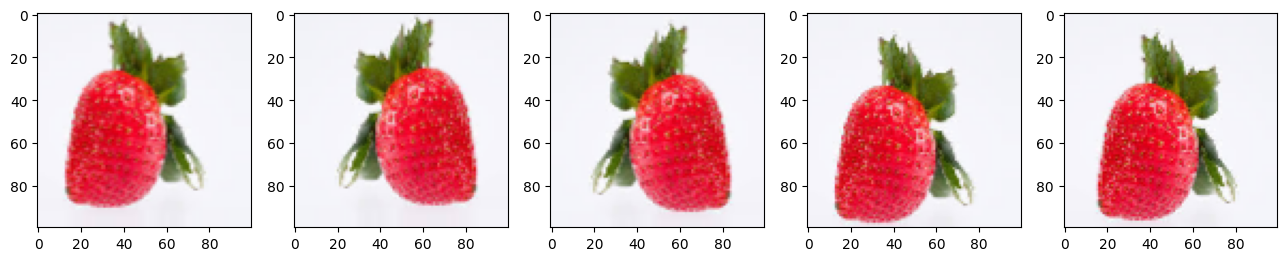

In [10]:
from pathlib import Path

IMG_DIM = (100, 100)

train_files = glob.glob('./Dataset/o-vs-r-split/train/O/*')
train_files = train_files[:20]
train_imgs = [tf.keras.preprocessing.image.img_to_array(tf.keras.preprocessing.image.load_img(img, target_size=IMG_DIM)) for img in train_files]
train_imgs = np.array(train_imgs)
train_labels = [Path(fn).parent.name for fn in train_files]

img_id = 0
O_generator = train_datagen.flow(train_imgs[img_id:img_id+1], train_labels[img_id:img_id+1],
                                   batch_size=1)
O = [next(O_generator) for i in range(0,5)]
fig, ax = plt.subplots(1,5, figsize=(16, 6))
print('Labels:', [item[1][0] for item in O])
l = [ax[i].imshow(O[i][0][0]) for i in range(0,5)]

### <a id='toc1_8_1_'></a>[Pre-trained Models](#toc0_)

Pre-trained models are saved networks that have previously been trained on some large datasets. They are typically used for large-scale image-classification task. They can be used as they are or could be customized to a given task using transfer learning. These pre-trained models form the basis of transfer learning.

#### <a id='toc1_8_1_1_'></a>[VGG-16](#toc0_)

Let us load the VGG16 model.


In [11]:
from tensorflow.keras.applications import vgg16

input_shape = (150, 150, 3)
vgg = vgg16.VGG16(include_top=False,
                        weights='imagenet',
                        input_shape=input_shape)

We flatten the output of a vgg model and assign it to the model `output`, we then use a Model object `basemodel` to group the layers into an object for training and inference .
With the following inputs and outputs

inputs: `vgg.input`

outputs: `tf.keras.layers.Flatten()(output)`


In [12]:
output = vgg.layers[-1].output
output = tf.keras.layers.Flatten()(output)
basemodel = Model(vgg.input, output)

Next, we freeze the basemodel.


In [13]:
for layer in basemodel.layers: 
    layer.trainable = False

Create a new model on top. You add a Dropout layer for regularization, only these layers will change as for the lower layers you set `training=False` when calling the base model.


In [14]:
input_shape = basemodel.output_shape[1]

model = Sequential()
model.add(basemodel)
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 model (Functional)          (None, 8192)              14714688  
                                                                 
 dense (Dense)               (None, 512)               4194816   
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 512)               262656    
                                                                 
 dropout_1 (Dropout)         (None, 512)               0         
                                                                 
 dense_2 (Dense)             (None, 1)                 513       
                                                                 
Total params: 19172673 (73.14 MB)
Trainable params: 4457

### <a id='toc1_10_'></a>[Compile the model](#toc0_)


In [ ]:
for layer in basemodel.layers: 
    layer.trainable = False

model.compile(
    loss= "binary_crossentropy",
    optimizer = optimizers.RMSprop(learning_rate =1e-4),
    metrics= ['accuracy']
)

We will use early stopping to avoid over-training the model.


In [18]:
import time
from tensorflow.keras.callbacks import LearningRateScheduler

checkpoint_path = f"O_R_tlearn_vgg16_{int(time.time())}.h5"

# define step decay function
class LossHistory_(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.losses = []
        self.lr = []
        
    def on_epoch_end(self, epoch, logs={}):
        self.losses.append(logs.get('loss'))
        self.lr.append(exp_decay(epoch))
        print('lr:', exp_decay(len(self.losses)))

def exp_decay(epoch):
    initial_lrate = 1e-4
    k = 0.1
    lrate = initial_lrate * np.exp(-k*epoch)
    return lrate

# learning schedule callback
loss_history_ = LossHistory_()
lrate_ = LearningRateScheduler(exp_decay)

keras_callbacks = [
      EarlyStopping(monitor = 'val_loss', 
                    patience = 4, 
                    mode = 'min', 
                    min_delta=0.01),
      ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, mode='min',  save_format='h5')
]

callbacks_list_ = [loss_history_, lrate_] + keras_callbacks

### <a id='toc1_11_'></a>[Fit and train the model](#toc0_)


In [19]:
extract_feat_model = model.fit(train_generator, 
                               steps_per_epoch=5, 
                               epochs=10,
                               callbacks = callbacks_list_,   
                               validation_data = val_generator, 
                               validation_steps = val_generator.samples // batch_size, 
                               verbose=1)

Epoch 1/10
5/5 [==============================] - 97s 16s/step - loss: 0.6305 - accuracy: 0.6250 - val_loss: 0.6743 - val_accuracy: 0.5312 - lr: 1.0000e-04
Epoch 2/10
5/5 [==============================] - 65s 14s/step - loss: 0.5781 - accuracy: 0.6938 - val_loss: 0.5486 - val_accuracy: 0.6719 - lr: 9.0484e-05
Epoch 3/10
5/5 [==============================] - 65s 14s/step - loss: 0.5220 - accuracy: 0.7688 - val_loss: 0.4526 - val_accuracy: 0.8281 - lr: 8.1873e-05
Epoch 4/10
5/5 [==============================] - 61s 14s/step - loss: 0.4728 - accuracy: 0.7812 - val_loss: 0.3850 - val_accuracy: 0.8750 - lr: 7.4082e-05
Epoch 5/10
5/5 [==============================] - 62s 14s/step - loss: 0.4639 - accuracy: 0.7937 - val_loss: 0.3768 - val_accuracy: 0.8333 - lr: 6.7032e-05
Epoch 6/10
5/5 [==============================] - 61s 14s/step - loss: 0.3927 - accuracy: 0.8375 - val_loss: 0.3563 - val_accuracy: 0.8646 - lr: 6.0653e-05
Epoch 7/10
5/5 [==============================] - 60s 14s/step -

### <a id='toc1_11_1_'></a>[Plot loss curves for training and validation sets (extract_feat_model)](#toc0_)


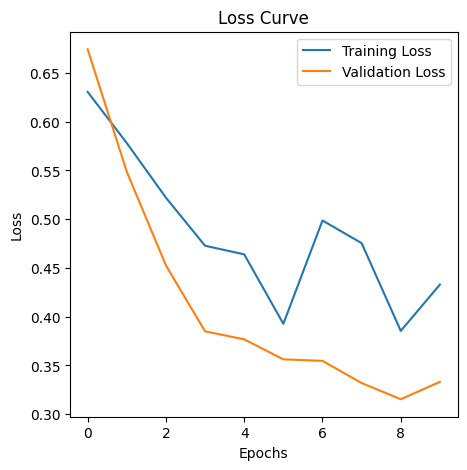

In [ ]:
import matplotlib.pyplot as plt
history = extract_feat_model

# plot loss curve
plt.figure(figsize=(5, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### <a id='toc1_11_2_'></a>[Plot accuracy curves for training and validation sets (extract_feat_model)](#toc0_)

As training is a stochastic process, the loss and accuracy graphs may differ across runs. As long as the general trend shows decreasing loss and increasing accuracy, the model is performing as expected.


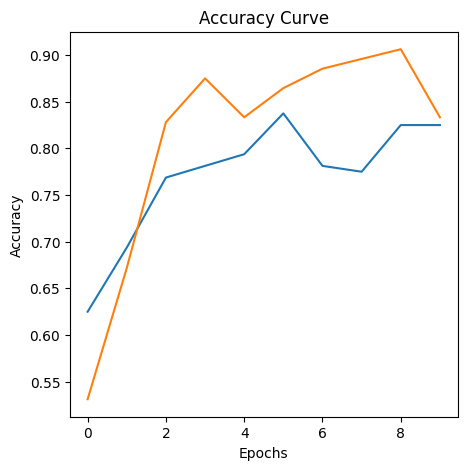

In [ ]:
import matplotlib.pyplot as plt
history = extract_feat_model

plt.figure(figsize=(5, 5))
# Plot training & validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
# Add title and labels
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
# Display plot
plt.show()

## <a id='toc1_12_'></a>[Fine-Tuning model](#toc0_)

Fine-tuning is an optional step in transfer learning, it usually ends up improving the performance of the model. 

we will **unfreeze** one layer from the base model and train the model again.


In [22]:
from tensorflow.keras.applications import vgg16

input_shape = (150, 150, 3)
vgg = vgg16.VGG16(include_top=False,
                        weights='imagenet',
                        input_shape=input_shape)

output = vgg.layers[-1].output
output = tf.keras.layers.Flatten()(output)
basemodel = Model(vgg.input, output)

for layer in basemodel.layers: 
    layer.trainable = False

display([layer.name for layer in basemodel.layers])

set_trainable = False

for layer in basemodel.layers:
    if layer.name in ['block5_conv3']:
        set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False

for layer in basemodel.layers:
    print(f"{layer.name}: {layer.trainable}")

['input_2',
 'block1_conv1',
 'block1_conv2',
 'block1_pool',
 'block2_conv1',
 'block2_conv2',
 'block2_pool',
 'block3_conv1',
 'block3_conv2',
 'block3_conv3',
 'block3_pool',
 'block4_conv1',
 'block4_conv2',
 'block4_conv3',
 'block4_pool',
 'block5_conv1',
 'block5_conv2',
 'block5_conv3',
 'block5_pool',
 'flatten_1']

input_2: False
block1_conv1: False
block1_conv2: False
block1_pool: False
block2_conv1: False
block2_conv2: False
block2_pool: False
block3_conv1: False
block3_conv2: False
block3_conv3: False
block3_pool: False
block4_conv1: False
block4_conv2: False
block4_conv3: False
block4_pool: False
block5_conv1: False
block5_conv2: False
block5_conv3: True
block5_pool: True
flatten_1: True


Similar to what we did before, we will create a new model on top, and add a Dropout layer for regularization.


In [24]:
model = Sequential()
model.add(basemodel)
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

checkpoint_path=f"O_R_tlearn_fine_tune_vgg16_{int(time.time())}.h5"

# learning schedule callback
loss_history_ = LossHistory_()
lrate_ = LearningRateScheduler(exp_decay)

keras_callbacks = [
      EarlyStopping(monitor = 'val_loss', 
                    patience = 4, 
                    mode = 'min', 
                    min_delta=0.01),
      ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, mode='min', save_format='h5')
]

callbacks_list_ = [loss_history_, lrate_] + keras_callbacks

model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-4),
              metrics=['accuracy'])

fine_tune_model = model.fit(train_generator, 
                    steps_per_epoch=5, 
                    epochs=10,
                    callbacks = callbacks_list_,   
                    validation_data=val_generator, 
                    validation_steps=val_generator.samples // batch_size, 
                    verbose=1)

Epoch 1/10
5/5 [==============================] - 74s 17s/step - loss: 0.8346 - accuracy: 0.5312 - val_loss: 0.5907 - val_accuracy: 0.6771 - lr: 1.0000e-04
Epoch 2/10
5/5 [==============================] - 104s 24s/step - loss: 0.5389 - accuracy: 0.7563 - val_loss: 0.4993 - val_accuracy: 0.7865 - lr: 9.0484e-05
Epoch 3/10
5/5 [==============================] - 81s 17s/step - loss: 0.5441 - accuracy: 0.7063 - val_loss: 0.4466 - val_accuracy: 0.8385 - lr: 8.1873e-05
Epoch 4/10
5/5 [==============================] - 70s 15s/step - loss: 0.4278 - accuracy: 0.8250 - val_loss: 0.4141 - val_accuracy: 0.8073 - lr: 7.4082e-05
Epoch 5/10
5/5 [==============================] - 68s 15s/step - loss: 0.4454 - accuracy: 0.8125 - val_loss: 0.3539 - val_accuracy: 0.8594 - lr: 6.7032e-05
Epoch 6/10
5/5 [==============================] - 79s 18s/step - loss: 0.4195 - accuracy: 0.7875 - val_loss: 0.3521 - val_accuracy: 0.8594 - lr: 6.0653e-05
Epoch 7/10
5/5 [==============================] - 70s 15s/step 

### <a id='toc1_12_1_'></a>[Plot loss curves for training and validation sets (fine tune model)](#toc0_)


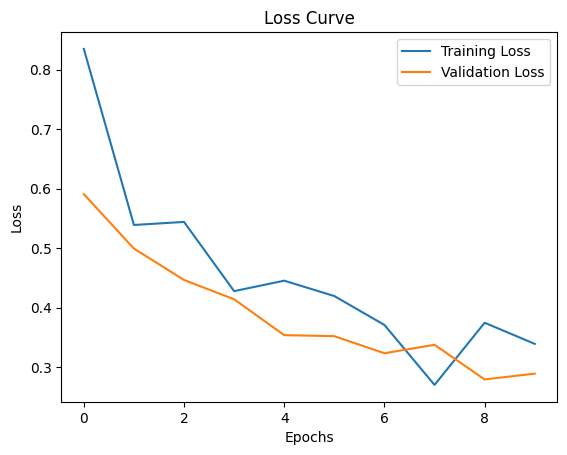

In [ ]:
history = fine_tune_model
figsize=(5, 5)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### <a id='toc1_12_2_'></a>[Plot accuracy curves for training and validation sets  (fine tune model)](#toc0_)

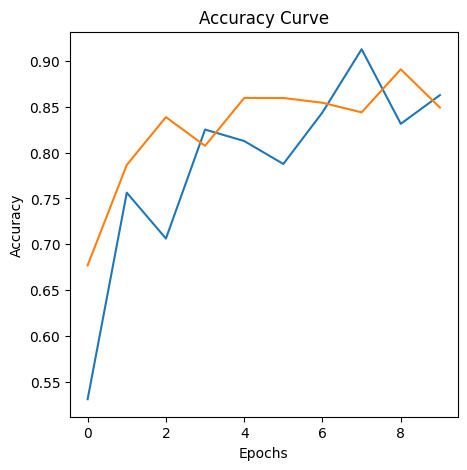

In [ ]:
history = fine_tune_model
plt.figure(figsize=(5, 5))
# Plot training & validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
# Add title and labels
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
# Display plot
plt.show()

## <a id='toc1_13_'></a>[Evaluate both models on test data](#toc0_)

- Load saved models
- Load test images
- Make predictions for both models
- Convert predictions to class labels
- Print classification report for both models


In [30]:
from pathlib import Path

# Load saved models
extract_feat_model = tf.keras.models.load_model('O_R_tlearn_vgg16_1754816585.h5')
fine_tune_model = tf.keras.models.load_model('O_R_tlearn_fine_tune_vgg16_1754818205.h5')

IMG_DIM = (150, 150)

# Load test images
test_files_O = glob.glob('./Dataset/o-vs-r-split/test/O/*')
test_files_R = glob.glob('./Dataset/o-vs-r-split/test/R/*')
test_files = test_files_O[:50] + test_files_R[:50]

test_imgs = [tf.keras.preprocessing.image.img_to_array(tf.keras.preprocessing.image.load_img(img, target_size=IMG_DIM)) for img in test_files]
test_imgs = np.array(test_imgs)
test_labels = [Path(fn).parent.name for fn in test_files]

# Standardize
test_imgs_scaled = test_imgs.astype('float32')
test_imgs_scaled /= 255

class2num_lt = lambda l: [0 if x == 'O' else 1 for x in l]
num2class_lt = lambda l: ['O' if x < 0.5 else 'R' for x in l]

test_labels_enc = class2num_lt(test_labels)

# Make predictions for both models
predictions_extract_feat_model = extract_feat_model.predict(test_imgs_scaled, verbose=0)
predictions_fine_tune_model = fine_tune_model.predict(test_imgs_scaled, verbose=0)

# Convert predictions to class labels
predictions_extract_feat_model = num2class_lt(predictions_extract_feat_model)
predictions_fine_tune_model = num2class_lt(predictions_fine_tune_model)

# Print classification report for both models
print('Extract Features Model')
print(metrics.classification_report(test_labels, predictions_extract_feat_model))
print('Fine-Tuned Model')
print(metrics.classification_report(test_labels, predictions_fine_tune_model))


Extract Features Model
              precision    recall  f1-score   support

           O       0.77      0.86      0.81        50
           R       0.84      0.74      0.79        50

    accuracy                           0.80       100
   macro avg       0.80      0.80      0.80       100
weighted avg       0.80      0.80      0.80       100

Fine-Tuned Model
              precision    recall  f1-score   support

           O       0.78      0.84      0.81        50
           R       0.83      0.76      0.79        50

    accuracy                           0.80       100
   macro avg       0.80      0.80      0.80       100
weighted avg       0.80      0.80      0.80       100



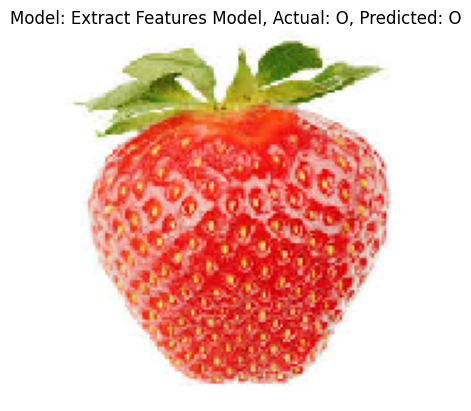

In [31]:
# Plot one of the images with actual label and predicted label as title
def plot_image_with_title(image, model_name, actual_label, predicted_label):
    plt.imshow(image)
    plt.title(f"Model: {model_name}, Actual: {actual_label}, Predicted: {predicted_label}")
    plt.axis('off')
    plt.show()

# Specify index of image to plot, for example index 0
index_to_plot = 0
plot_image_with_title(
    image=test_imgs[index_to_plot].astype('uint8'),
    model_name='Extract Features Model',
    actual_label=test_labels[index_to_plot], 
    predicted_label=predictions_extract_feat_model[index_to_plot],
    )

### <a id='toc1_13_1_'></a>[Plot a test image using Extract Features Model (index_to_plot = 1)](#toc0_)

Due to the inherent nature of neural networks, predictions may vary from the actual labels. For instance, if the actual label is ‘O’, the prediction could be either ‘O’ or ‘R’, both of which are possible outcomes.


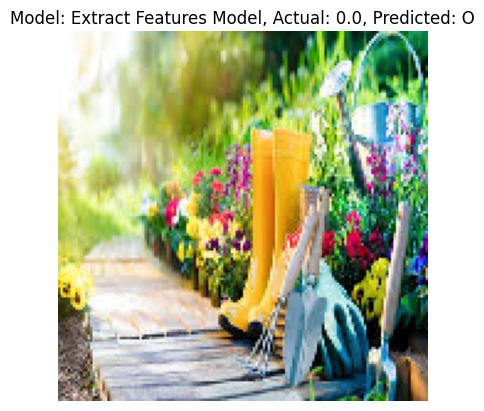

In [ ]:
index_to_plot = 1
plot_image_with_title(
    image=test_imgs[index_to_plot].astype('uint8'),
    model_name='Extract Features Model',
    actual_label=test_labels[index_to_plot], 
    predicted_label=predictions_extract_feat_model[index_to_plot],
)

### <a id='toc1_13_2_'></a>[Plot a test image using Fine-Tuned Model (index_to_plot = 1)](#toc0_)

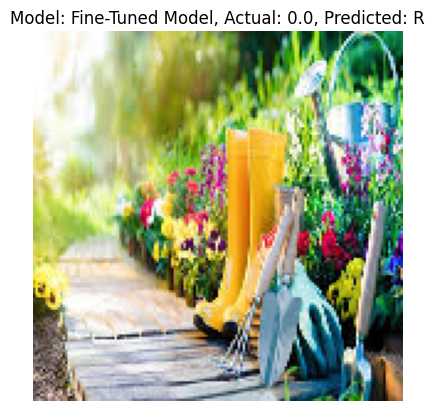

In [ ]:
index_to_plot = 1
plot_image_with_title(
    image=test_imgs[index_to_plot].astype('uint8'),
    model_name='Fine-Tuned Model',  
    actual_label=test_labels[index_to_plot],
    predicted_label=predictions_fine_tune_model[index_to_plot],
)